# Machine Learning / Data Science

In [81]:
import numpy as np
import pandas as pd 

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import cross_val_score, cross_val_predict, KFold, GridSearchCV

from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor

from sklearn import preprocessing
from sklearn.preprocessing import OneHotEncoder

import matplotlib.pyplot as plt
import joblib

In [82]:
df_pisos = pd.read_csv('idealista_machine_learning.csv')



In [83]:
df_pisos.head()

,titulo,localizacion,precio,ascensor,baños,trastero,piso,habitaciones,metros_reales,armarios_empotrados,terraza,garaje,calefaccion,aire_acondicionado,piscina,zonas_verdes
0,Alquiler de Piso en calle Jardines,"Recogidas, Granada",510,0.0,1,0,Primeros_pisos,1,35,0,0,0,1,0,0,0
1,Alquiler de Piso en Catedral,"Centro, Granada",1050,0.0,1,0,Ultimos_pisos,2,45,0,0,0,0,1,0,0
2,"Alquiler de Piso en plaza Aurora, 10","San Miguel, Armilla",550,1.0,1,0,Primeros_pisos,1,55,1,0,1,1,0,0,0
3,Alquiler de Ático en calle Zapateros,"Catedral, Granada",680,1.0,1,0,Primeros_pisos,1,60,0,0,0,0,0,0,0
4,Alquiler de Casa o chalet independiente en San...,Granada,2200,0.0,2,1,Muchas_plantas,4,2,0,1,1,1,1,1,0


In [84]:
#Eliminar pisos con pocos metros cuadrados mediante Umbral Dinamico
# Calcular el percentil 1% de la columna 'metros_reales'
# Esto se hace para eliminar outliers que puedan afectar el modelo
threshold = np.percentile(df_pisos['metros_reales'], 1)  # Percentil 1%
umbral_final = max(threshold, 20)  # Elige el mayor entre el percentil y 20
df_filtrado = df_pisos[df_pisos['metros_reales'] >= umbral_final]

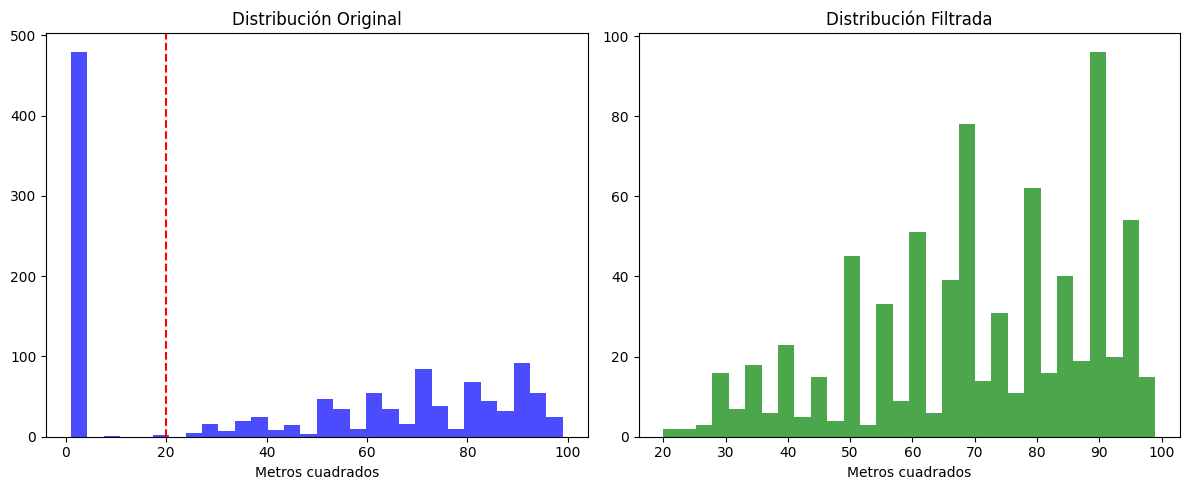

In [85]:
import matplotlib.pyplot as plt

# Histograma antes
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(df_pisos['metros_reales'], bins=30, color='blue', alpha=0.7)
plt.axvline(umbral_final, color='red', linestyle='--')
plt.title('Distribución Original')
plt.xlabel('Metros cuadrados')

# Histograma después
plt.subplot(1, 2, 2)
plt.hist(df_filtrado['metros_reales'], bins=30, color='green', alpha=0.7)
plt.title('Distribución Filtrada')
plt.xlabel('Metros cuadrados')

plt.tight_layout()
plt.show()

## Antes de hacer la divison en train y test, vamos hacer las transformaciones de variables categóricas a variables dummy o numéricas, para previnir posibles errores

Como en las variables categóricas no hay un orden determinado, haremos directamente un get_dummies

In [86]:
df_pisos = pd.get_dummies(df_filtrado, dtype='int', columns=["localizacion","piso"])

In [87]:
df_pisos.head()

,titulo,precio,ascensor,baños,trastero,habitaciones,metros_reales,armarios_empotrados,terraza,garaje,...,"localizacion_Zona Parque de San Roque, Churriana de la Vega","localizacion_Zona Parque de la Ermita, Churriana de la Vega","localizacion_Zona Polideportivo, Alhendin","localizacion_Zona Poniente, Armilla","localizacion_Zona de San Cayetano, Churriana de la Vega","localizacion_Área de Granada, Granada",piso_Bajo,piso_Muchas_plantas,piso_Primeros_pisos,piso_Ultimos_pisos
0,Alquiler de Piso en calle Jardines,510,0.0,1,0,1,35,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,Alquiler de Piso en Catedral,1050,0.0,1,0,2,45,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,"Alquiler de Piso en plaza Aurora, 10",550,1.0,1,0,1,55,1,0,1,...,0,0,0,0,0,0,0,0,1,0
3,Alquiler de Ático en calle Zapateros,680,1.0,1,0,1,60,0,0,0,...,0,0,0,0,0,0,0,0,1,0
5,Alquiler de Piso en calle Nicuesa,850,1.0,1,0,3,85,0,0,0,...,0,0,0,0,0,0,0,0,1,0


## Ridge regression Version rápida

Se dropean la columna precio porque es la que remos predecir y la columna titulo porque no nos aporta nada aparte de identificar el piso

In [88]:
x, y = df_pisos.drop(["precio","titulo"], axis=1), df_pisos["precio"]

In [89]:
vars_pisos = list(df_pisos.columns)
vars_pisos.remove('precio')
vars_pisos.remove('titulo')

model intercept: 311.677755


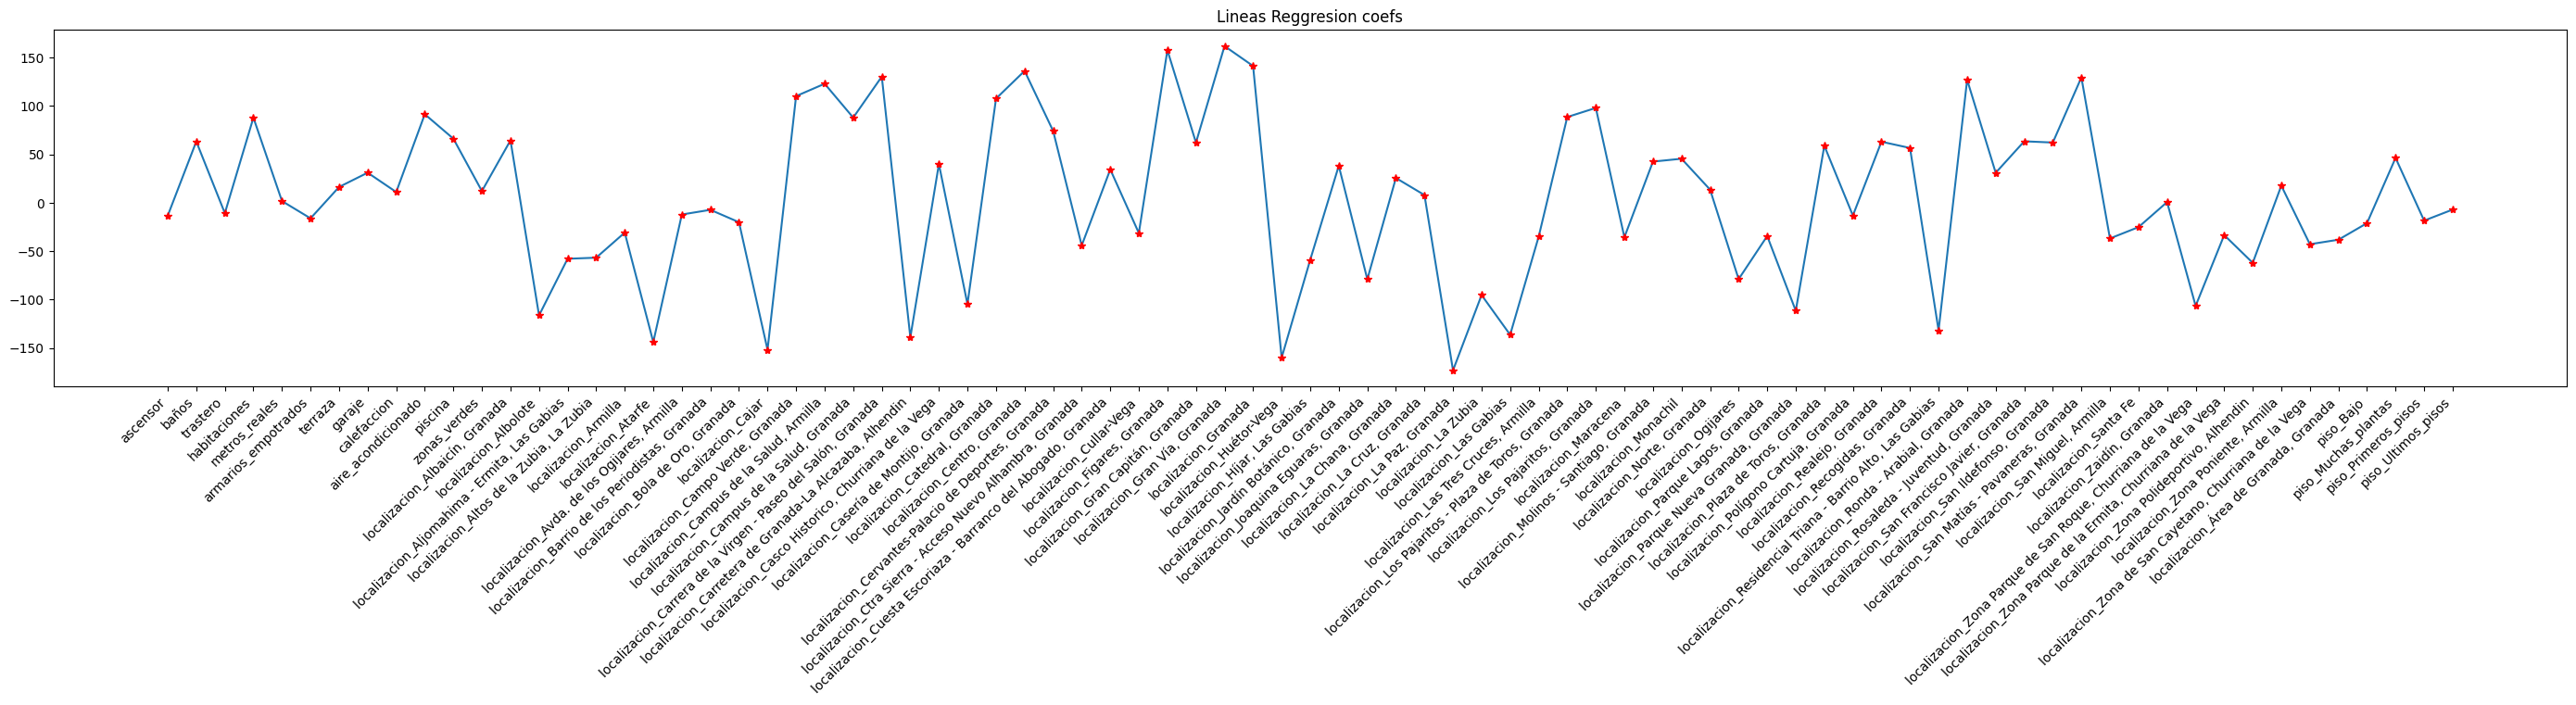

In [90]:
lr_m = Ridge()
#ajuste sobre la muestra completa, sin split traint-test
lr_m.fit(x, y)
print('model intercept: %f' % lr_m.intercept_)

plt.figure(figsize=(35,5))
plt.xticks(range(len(vars_pisos)), vars_pisos, rotation=45, ha='right')
plt.title('Lineas Reggresion coefs')
_ = plt.plot(lr_m.coef_.T, '-', lr_m.coef_.T, 'r*')


## Estimacion de precio con el MAE

MAE: 87.741	R^2: 0.582


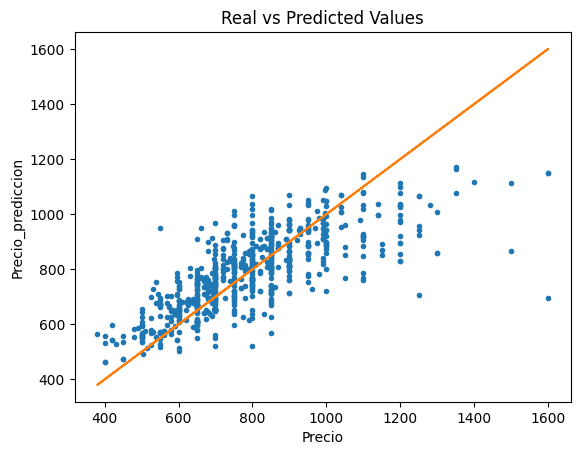

In [91]:
y_pred = lr_m.predict(x)

print("MAE: %.3f\tR^2: %.3f" % (mean_absolute_error(y, y_pred), lr_m.score(x, y)))

plt.title('Real vs Predicted Values')
plt.xlabel('Precio')
plt.ylabel('Precio_prediccion')

_ = plt.plot(y, y_pred, '.', y, y, '')

## Ahora estimamos mejor el MAE

In [92]:
from sklearn import model_selection

In [93]:
n_folds = 10
kf = KFold(n_folds, shuffle=True)

scores = cross_val_score(lr_m, x, y, scoring="neg_mean_absolute_error", cv=kf, n_jobs=-1)

print("mae_mean: %.3f\t\tmae_std: %.3f" % (-scores.mean(), scores.std()))
print("scores: \n", -np.round(scores, 3))

mae_mean: 96.685		mae_std: 9.128
scores: 
 [102.216  87.42  110.96  104.372  83.669 105.42  100.71   95.06   83.228
  93.796]


## Fine tuning

buscamos el mejor alpha

In [94]:
# First iteration to find alpha

# define fold
n_fold = 10
kf = KFold(n_folds, shuffle=True)

# define param_grid
l_alpha = [2.**k for k in range (-6, 10)]
param_grid = {'alpha': l_alpha}

# define grid search
lr_m = Ridge()
ridge_alpha_search = GridSearchCV(lr_m,
                                  param_grid=param_grid,
                                  cv=kf,
                                  scoring='neg_mean_absolute_error',
                                  n_jobs=1,
                                  verbose=1)

_ = ridge_alpha_search.fit(x, y)

Fitting 10 folds for each of 16 candidates, totalling 160 fits


alpha_range: 0.02 - 512.00
alpha = 0.50
best_cv_mae = 96.944


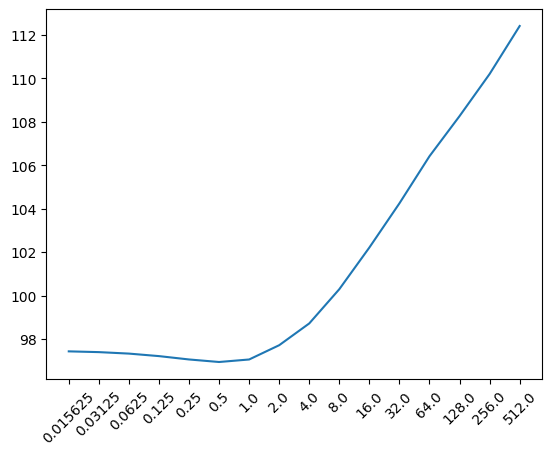

In [95]:
print("alpha_range: %.2f - %.2f" % (np.array(l_alpha).min(), np.array(l_alpha).max()))
print('alpha = %.2f' % (ridge_alpha_search.best_params_['alpha']))
print('best_cv_mae = %.3f' % (-ridge_alpha_search.best_score_))

plt.xticks(range(len(l_alpha)), l_alpha, rotation=45)
_ = plt.plot(-ridge_alpha_search.cv_results_['mean_test_score'])

In [96]:
#Segunda iteracion: recentramos alpha y refinamos la busqueda

kf = KFold(n_folds, shuffle=True)

# define param_grid
l_alpha = [2.0 * 2.**(k/2.) for k in range (-5, 4)]
param_grid = {'alpha': l_alpha}

# define grid search
lr_m = Ridge()
ridge_alpha_search = GridSearchCV(lr_m,
                                  param_grid=param_grid,
                                  cv=kf,
                                  scoring='neg_mean_absolute_error',
                                  n_jobs=2,
                                  verbose=1)

_ = ridge_alpha_search.fit(x, y)

Fitting 10 folds for each of 9 candidates, totalling 90 fits


alpha_range: 0.35 - 5.66
alpha = 0.50
best_cv_mae = 97.417


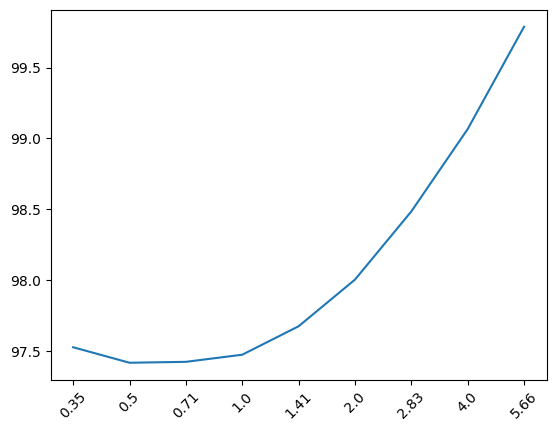

In [97]:
print("alpha_range: %.2f - %.2f" % (np.array(l_alpha).min(), np.array(l_alpha).max()))
print('alpha = %.2f' % (ridge_alpha_search.best_params_['alpha']))
print('best_cv_mae = %.3f' % (-ridge_alpha_search.best_score_))

plt.xticks(range(len(l_alpha)), np.round(l_alpha, 2), rotation=45)
_ = plt.plot(-ridge_alpha_search.cv_results_['mean_test_score'])

Aunque hemos encontrao un alpha mejor (2.83) el error de mae ha aumentado. Se realiza una tercera busqueda para encontrar un resultado mejor

In [98]:
#Tercera iteracion: recentramos alpha y refinamos la busqueda

kf = KFold(n_folds, shuffle=True)

# Exploracion mas fina entre 1.5 y 3.5
l_alpha = [2.0 * 2.**(k/4.) for k in range (-4, 4)]
param_grid = {'alpha': l_alpha}

# define grid search
lr_m = Ridge()
ridge_alpha_search = GridSearchCV(lr_m,
                                  param_grid=param_grid,
                                  cv=kf,
                                  scoring='neg_mean_absolute_error',
                                  n_jobs=2,
                                  verbose=1)

_ = ridge_alpha_search.fit(x, y)

Fitting 10 folds for each of 8 candidates, totalling 80 fits


alpha_range: 1.00 - 3.36
alpha = 1.00
best_cv_mae = 97.274


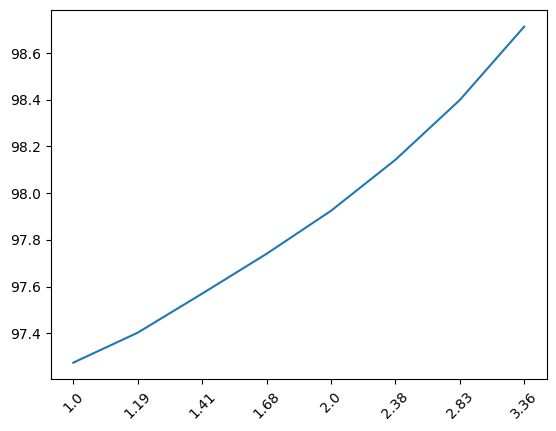

In [99]:
print("alpha_range: %.2f - %.2f" % (np.array(l_alpha).min(), np.array(l_alpha).max()))
print('alpha = %.2f' % (ridge_alpha_search.best_params_['alpha']))
print('best_cv_mae = %.3f' % (-ridge_alpha_search.best_score_))

plt.xticks(range(len(l_alpha)), np.round(l_alpha, 2), rotation=45)
_ = plt.plot(-ridge_alpha_search.cv_results_['mean_test_score'])

Comprobamos que el mejor alpha vuelve a ser 2 y con el hemos obteneido un error de mae ligeramente mejor que el del inicio.

Conclusion: Nos quedamos con el alpha 2

In [100]:
from sklearn.metrics import r2_score
best_alpha = ridge_alpha_search.best_params_['alpha']
print("best_alpha: %.2f" % best_alpha)
lr_m = Ridge(alpha=best_alpha) # fit final model

scores = cross_val_score(lr_m, x, y, scoring="neg_mean_absolute_error", cv=kf, n_jobs=2)

print("mae_mean: %.3f\t\tmae_std: %.3f" % (-scores.mean(), scores.std()))

r2_final = r2_score(y, y_pred)
print("R² final: %.3f" % r2_final)

best_alpha: 1.00
mae_mean: 96.432		mae_std: 10.567
R² final: 0.582


Volvemos a predecir con el coeficiente (alpha) optimizado

In [101]:
y_pred = cross_val_predict(lr_m, x, y)

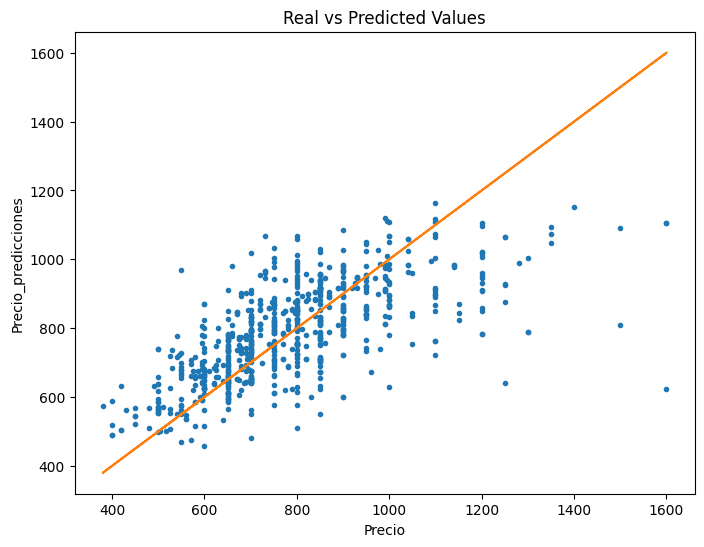

In [102]:
plt.figure(figsize=(8, 6))
plt.title('Real vs Predicted Values')
plt.xlabel('Precio')
plt.ylabel('Precio_predicciones')

_ = plt.plot(y, y_pred, '.', y, y, '')

Juntar los datos que teniamos con la prediccion para comparar cuales son las casas que valen mas o menos de lo que esta en idealista

In [103]:
df_pisos_final = df_pisos.copy()
precio_pred = np.round(y_pred)
df_pisos_final.insert(2, 'precio_pred',precio_pred)
df_pisos_final

,titulo,precio,precio_pred,ascensor,baños,trastero,habitaciones,metros_reales,armarios_empotrados,terraza,...,"localizacion_Zona Parque de San Roque, Churriana de la Vega","localizacion_Zona Parque de la Ermita, Churriana de la Vega","localizacion_Zona Polideportivo, Alhendin","localizacion_Zona Poniente, Armilla","localizacion_Zona de San Cayetano, Churriana de la Vega","localizacion_Área de Granada, Granada",piso_Bajo,piso_Muchas_plantas,piso_Primeros_pisos,piso_Ultimos_pisos
0,Alquiler de Piso en calle Jardines,510,570.0,0.0,1,0,1,35,0,0,...,0,0,0,0,0,0,0,0,1,0
1,Alquiler de Piso en Catedral,1050,844.0,0.0,1,0,2,45,0,0,...,0,0,0,0,0,0,0,0,0,1
2,"Alquiler de Piso en plaza Aurora, 10",550,469.0,1.0,1,0,1,55,1,0,...,0,0,0,0,0,0,0,0,1,0
3,Alquiler de Ático en calle Zapateros,680,620.0,1.0,1,0,1,60,0,0,...,0,0,0,0,0,0,0,0,1,0
5,Alquiler de Piso en calle Nicuesa,850,902.0,1.0,1,0,3,85,0,0,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1214,"Alquiler de Piso en avenida Don Bosco, 21",800,756.0,1.0,1,0,3,86,1,0,...,0,0,0,0,0,0,0,0,1,0
1215,"Alquiler de Piso en calle Buensuceso, 25",990,835.0,0.0,1,0,2,90,1,1,...,0,0,0,0,0,0,0,0,1,0
1216,"Alquiler de Estudio en calle Madrid, 74",500,497.0,1.0,1,0,1,50,0,0,...,0,0,0,0,0,0,1,0,0,0
1219,"Alquiler de Piso en Placeta de Aljucer, 1",800,801.0,0.0,1,0,3,70,0,0,...,0,0,0,0,0,0,0,0,1,0


In [104]:
#Encontrar casas por debajo de 800 y cuyo precio real este por debajo del previsto
df_pisos_final[(df_pisos_final.precio < 800) & (df_pisos_final.precio < df_pisos_final.precio_pred)]

,titulo,precio,precio_pred,ascensor,baños,trastero,habitaciones,metros_reales,armarios_empotrados,terraza,...,"localizacion_Zona Parque de San Roque, Churriana de la Vega","localizacion_Zona Parque de la Ermita, Churriana de la Vega","localizacion_Zona Polideportivo, Alhendin","localizacion_Zona Poniente, Armilla","localizacion_Zona de San Cayetano, Churriana de la Vega","localizacion_Área de Granada, Granada",piso_Bajo,piso_Muchas_plantas,piso_Primeros_pisos,piso_Ultimos_pisos
0,Alquiler de Piso en calle Jardines,510,570.0,0.0,1,0,1,35,0,0,...,0,0,0,0,0,0,0,0,1,0
6,Alquiler de Piso en calle Ganivet,600,659.0,1.0,1,0,1,67,0,0,...,0,0,0,1,0,0,0,0,1,0
11,"Alquiler de Piso en plaza del Realejo, 2",750,818.0,1.0,1,0,2,80,1,0,...,0,0,0,0,0,0,1,0,0,0
12,Alquiler de Piso en plaza de Santo Domingo,650,658.0,1.0,1,0,1,60,1,0,...,0,0,0,0,0,0,0,0,1,0
15,Alquiler de Estudio en Molinos - Santiago,420,633.0,0.0,1,0,1,45,0,0,...,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1197,Alquiler de Piso en Jardín Botánico,650,664.0,0.0,1,0,1,50,0,0,...,0,0,0,0,0,0,0,0,1,0
1200,Alquiler de Piso en Cervantes-Palacio de Deportes,680,892.0,1.0,1,0,2,80,1,0,...,0,0,0,0,0,0,0,0,1,0
1201,Alquiler de Piso en calle Poeta César Vallejo,750,764.0,1.0,1,0,3,96,0,1,...,0,0,0,0,0,0,1,0,0,0
1202,"Alquiler de Piso en calle Valencia, 36",580,635.0,1.0,1,0,2,80,1,0,...,0,1,0,0,0,0,0,0,1,0


In [105]:
lr_m.fit(x,y)

Ridge()

In [106]:
pd.DataFrame(lr_m.coef_,
             vars_pisos,
             columns=['coef'])\
            .sort_values(by='coef', ascending=False)

,coef
"localizacion_Gran Vía, Granada",161.840011
"localizacion_Figares, Granada",157.554489
localizacion_Granada,141.267675
"localizacion_Centro, Granada",136.188731
"localizacion_Carrera de la Virgen - Paseo del Salón, Granada",130.306156
...,...
"localizacion_Carretera de Granada-La Alcazaba, Alhendin",-138.867023
localizacion_Atarfe,-143.783834
localizacion_Cajar,-151.707030
localizacion_Huétor-Vega,-159.913832


In [107]:
import seaborn as sns

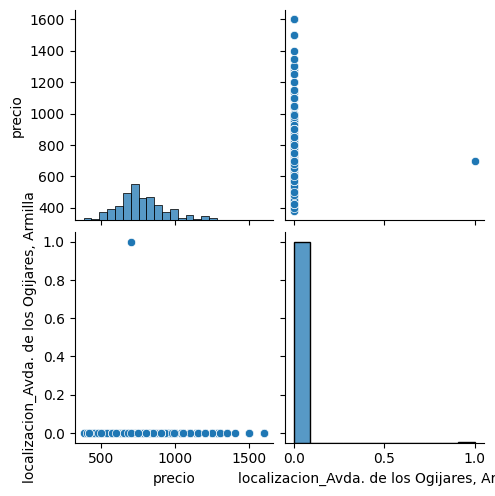

In [108]:
sns.pairplot(df_pisos[['precio', 'localizacion_Avda. de los Ogijares, Armilla']])

# Exportar modelo y enconders

In [109]:
import pickle
# Guardar el modelo
with open('modelo_ridge.pkl', 'wb') as f:
    pickle.dump(lr_m, f)


In [110]:

features = df_pisos.drop(columns=['titulo', 'precio']).columns
np.save('encoded_columns.npy', df_pisos.columns.values)